# 📊 Notebook 3.1 — Escalamiento y Normalización de Variables
## 

**Objetivo:** Entender por qué y cómo escalar variables en un contexto de seguros.  


In [6]:
# Instalación e importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. ¿Por qué necesitamos escalar? 🤔

Imagina que tienes dos variables en una póliza de seguro de auto:
- **Edad del conductor**: 18 a 80 años
- **Prima anual**: $5,000 a $150,000 pesos

Si un modelo compara estas variables directamente, la prima domina completamente por su magnitud. El escalamiento soluciona esto.


In [7]:
# Crear dataset actuarial de ejemplo
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'edad_conductor': np.random.randint(18, 80, n),
    'antiguedad_licencia': np.random.randint(0, 45, n),
    'prima_anual': np.random.lognormal(mean=10, sigma=0.8, size=n).clip(5000, 150000),
    'suma_asegurada': np.random.lognormal(mean=13, sigma=0.5, size=n).clip(100000, 5000000),
    'num_siniestros_previos': np.random.poisson(lam=0.3, size=n),
})

print("📋 Primeras 5 filas del dataset:")
print(df.head())
print(f"\n📊 Estadísticas descriptivas:")
print(df.describe().round(2))


📋 Primeras 5 filas del dataset:
   edad_conductor  antiguedad_licencia   prima_anual  suma_asegurada  \
0              56                   21  44067.562681    6.068628e+05   
1              69                   22  32107.003572    2.712013e+05   
2              46                    1  16538.274489    5.275218e+05   
3              32                   26  45319.412406    4.727823e+05   
4              60                   41  10970.909910    1.035969e+06   

   num_siniestros_previos  
0                       1  
1                       0  
2                       1  
3                       0  
4                       1  

📊 Estadísticas descriptivas:
       edad_conductor  antiguedad_licencia  prima_anual  suma_asegurada  \
count          500.00               500.00       500.00          500.00   
mean            49.91                21.78     33707.36       522252.28   
std             18.22                12.69     30977.12       280798.88   
min             18.00                

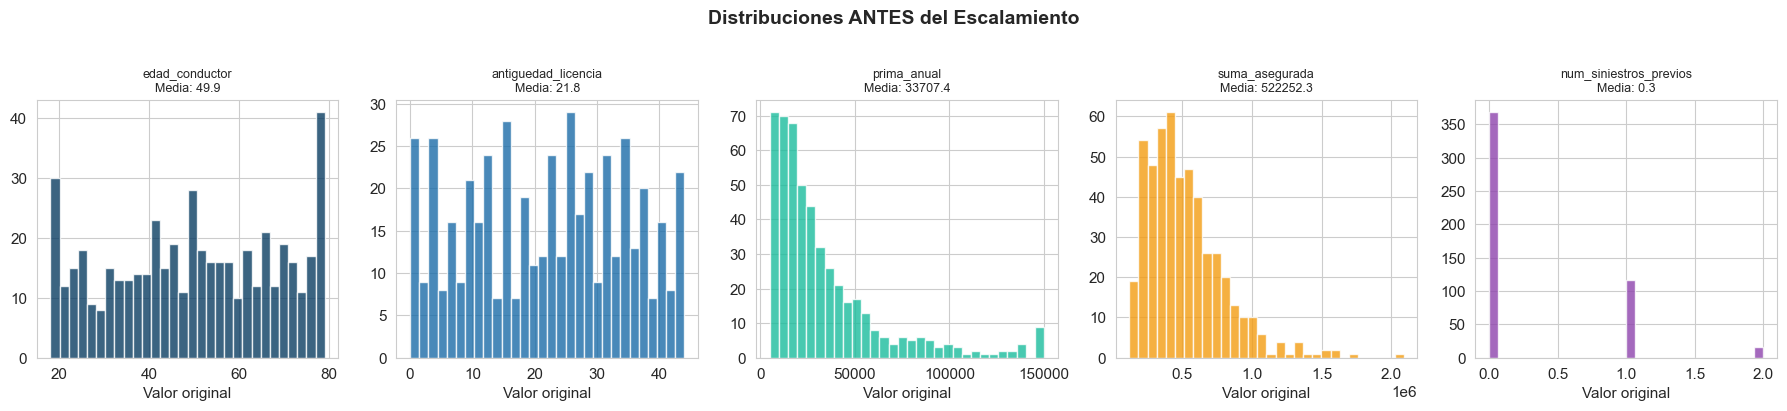

💡 Observa cómo prima_anual y suma_asegurada tienen rangos MUCHO mayores que edad


In [8]:
# Visualizar distribuciones ANTES del escalamiento
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cols = df.columns.tolist()
colors = ['#0A3D62', '#1B6CA8', '#1ABC9C', '#F39C12', '#8E44AD']

for i, (col, ax, c) in enumerate(zip(cols, axes, colors)):
    ax.hist(df[col], bins=30, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\nMedia: {df[col].mean():.1f}', fontsize=9)
    ax.set_xlabel('Valor original')

plt.suptitle('Distribuciones ANTES del Escalamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('escala_antes.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Observa cómo prima_anual y suma_asegurada tienen rangos MUCHO mayores que edad")


## 2. Min-Max Scaling (Normalización)

**Fórmula:** `X' = (X - X_min) / (X_max - X_min)`

Transforma todas las variables al rango [0, 1].


In [9]:
# Aplicar Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df),
    columns=[f'{c}_mm' for c in df.columns]
)

print("📊 Estadísticas DESPUÉS de Min-Max:")
print(df_minmax.describe().round(4))
print("\n✅ Todos los valores están entre 0 y 1")

# Verificar con un ejemplo manual
prima_ejemplo = 75000
prima_norm = (prima_ejemplo - df['prima_anual'].min()) / (df['prima_anual'].max() - df['prima_anual'].min())
print(f"\n🔍 Ejemplo manual:")
print(f"   Prima = ${prima_ejemplo:,}")
print(f"   Prima normalizada = {prima_norm:.4f}")
print(f"   Verificación con sklearn: {scaler_minmax.transform([[df.loc[0,'edad_conductor'], df.loc[0,'antiguedad_licencia'], prima_ejemplo, df.loc[0,'suma_asegurada'], df.loc[0,'num_siniestros_previos']]])[0][2]:.4f}")


📊 Estadísticas DESPUÉS de Min-Max:
       edad_conductor_mm  antiguedad_licencia_mm  prima_anual_mm  \
count           500.0000                500.0000        500.0000   
mean              0.5231                  0.4949          0.1980   
std               0.2987                  0.2884          0.2136   
min               0.0000                  0.0000          0.0000   
25%               0.2787                  0.2500          0.0578   
50%               0.5246                  0.5000          0.1260   
75%               0.7869                  0.7273          0.2575   
max               1.0000                  1.0000          1.0000   

       suma_asegurada_mm  num_siniestros_previos_mm  
count           500.0000                   500.0000  
mean              0.2042                     0.1480  
std               0.1426                     0.2612  
min               0.0000                     0.0000  
25%               0.1051                     0.0000  
50%               0.1735    

## 3. Estandarización Z-Score

**Fórmula:** `Z = (X - μ) / σ`

Transforma las variables para que tengan **media = 0** y **desviación estándar = 1**.


In [10]:
# Aplicar Z-Score Standardization
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(
    scaler_zscore.fit_transform(df),
    columns=[f'{c}_z' for c in df.columns]
)

print("📊 Estadísticas DESPUÉS de Z-Score:")
print(df_zscore.describe().round(4))
print("\n✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1")

# Cálculo manual para verificar
col = 'prima_anual'
mu = df[col].mean()
sigma = df[col].std()
prima_z = (df[col] - mu) / sigma
print(f"\n🔍 Z-Score de prima_anual:")
print(f"   Media original: ${mu:,.0f}")
print(f"   Desv. Est.: ${sigma:,.0f}")
print(f"   Primer valor original: ${df[col].iloc[0]:,.0f}")
print(f"   Primer valor Z: {prima_z.iloc[0]:.4f}")
print(f"   Interpretación: está {prima_z.iloc[0]:.2f} desviaciones estándar de la media")


📊 Estadísticas DESPUÉS de Z-Score:
       edad_conductor_z  antiguedad_licencia_z  prima_anual_z  \
count          500.0000               500.0000       500.0000   
mean             0.0000                 0.0000         0.0000   
std              1.0010                 1.0010         1.0010   
min             -1.7529                -1.7179        -0.9277   
25%             -0.8191                -0.8501        -0.6567   
50%              0.0049                 0.0177        -0.3371   
75%              0.8839                 0.8066         0.2791   
max              1.5980                 1.7532         3.7579   

       suma_asegurada_z  num_siniestros_previos_z  
count          500.0000                  500.0000  
mean             0.0000                   -0.0000  
std              1.0010                    1.0010  
min             -1.4340                   -0.5672  
25%             -0.6959                   -0.5672  
50%             -0.2162                   -0.5672  
75%            

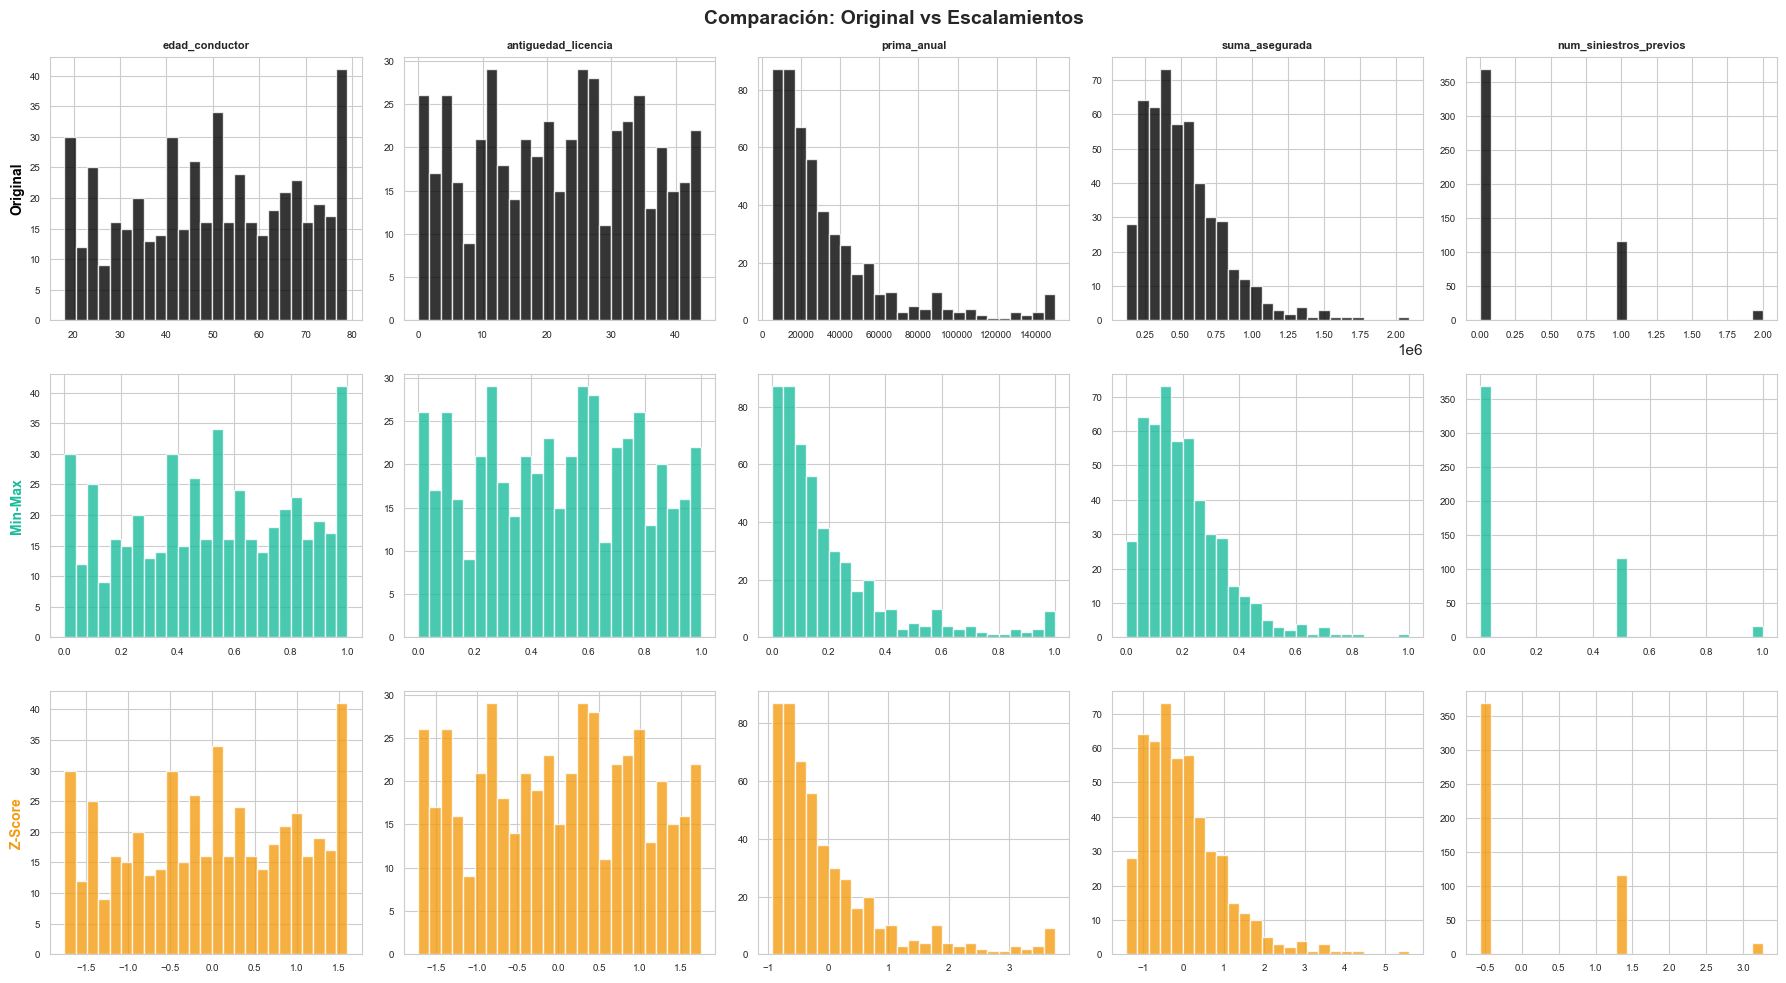

In [11]:
# Comparación visual: Original vs MinMax vs ZScore
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
col_names = df.columns.tolist()
titles = ['Original', 'Min-Max', 'Z-Score']
datasets = [df, df_minmax, df_zscore]
colors = ["#020203", '#1ABC9C', '#F39C12']

for row, (data, title, c) in enumerate(zip(datasets, titles, colors)):
    for col_idx, col in enumerate(data.columns):
        ax = axes[row, col_idx]
        ax.hist(data[col], bins=25, color=c, alpha=0.8, edgecolor='white')
        if row == 0:
            ax.set_title(col_names[col_idx], fontsize=8, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(title, fontsize=10, fontweight='bold', color=c)
        ax.tick_params(labelsize=7)

plt.suptitle('Comparación: Original vs Escalamientos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_escalamiento.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Robust Scaler — Para datos con outliers

Usa la **mediana** y el **rango intercuartil (IQR)** en lugar de media y desviación estándar.
Ideal cuando hay siniestros extremos o primas atípicas.


🚨 Estadísticas CON outliers en prima_anual:
  Media:  $      68,512
  Mediana: $     23,423
  Max:     $  4,299,151
  Min:     $      5,000


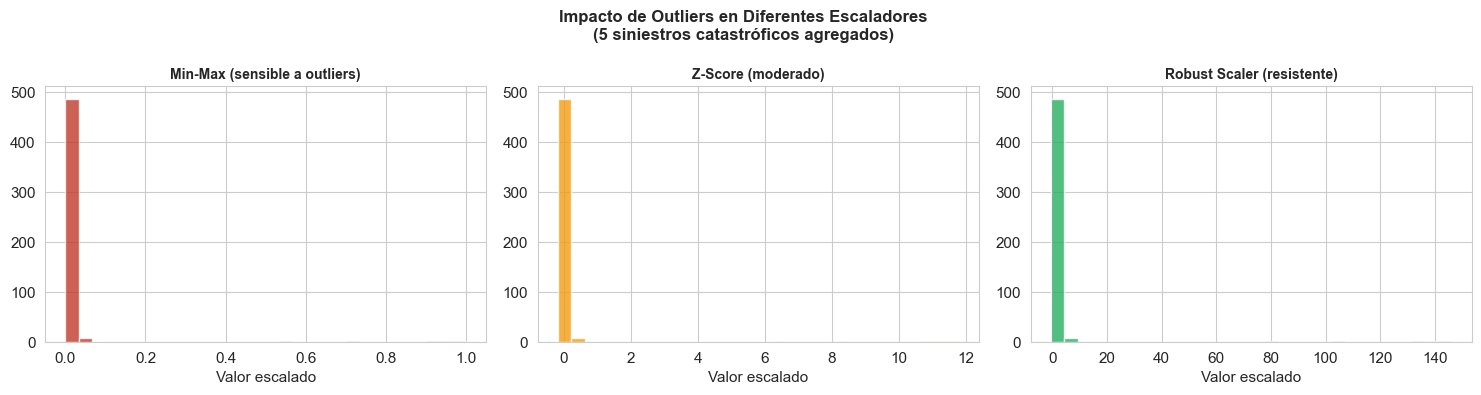


✅ Robust Scaler comprime los outliers sin distorsionar el resto


In [12]:
# Simular datos con outliers extremos (siniestros catastróficos)
df_con_outliers = df.copy()
# Agregar 5 siniestros con prima muy alta (catastróficos)
outlier_indices = np.random.choice(n, 5, replace=False)
df_con_outliers.loc[outlier_indices, 'prima_anual'] = np.random.uniform(1_000_000, 5_000_000, 5)

print("🚨 Estadísticas CON outliers en prima_anual:")
print(f"  Media:  ${df_con_outliers['prima_anual'].mean():>12,.0f}")
print(f"  Mediana: ${df_con_outliers['prima_anual'].median():>11,.0f}")
print(f"  Max:     ${df_con_outliers['prima_anual'].max():>11,.0f}")
print(f"  Min:     ${df_con_outliers['prima_anual'].min():>11,.0f}")

# Comparar escaladores
scaler_robust = RobustScaler()
scaler_standard = StandardScaler()
scaler_mm_out = MinMaxScaler()

prima_col = df_con_outliers[['prima_anual']]
prima_robust = scaler_robust.fit_transform(prima_col).flatten()
prima_standard = scaler_standard.fit_transform(prima_col).flatten()
prima_mm = scaler_mm_out.fit_transform(prima_col).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Min-Max (sensible a outliers)', 'Z-Score (moderado)', 'Robust Scaler (resistente)']
datos = [prima_mm, prima_standard, prima_robust]
cols = ['#C0392B', '#F39C12', '#27AE60']

for ax, d, lab, c in zip(axes, datos, labels, cols):
    ax.hist(d, bins=30, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor escalado')

plt.suptitle('Impacto de Outliers en Diferentes Escaladores\n(5 siniestros catastróficos agregados)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('robust_scaler.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Robust Scaler comprime los outliers sin distorsionar el resto")


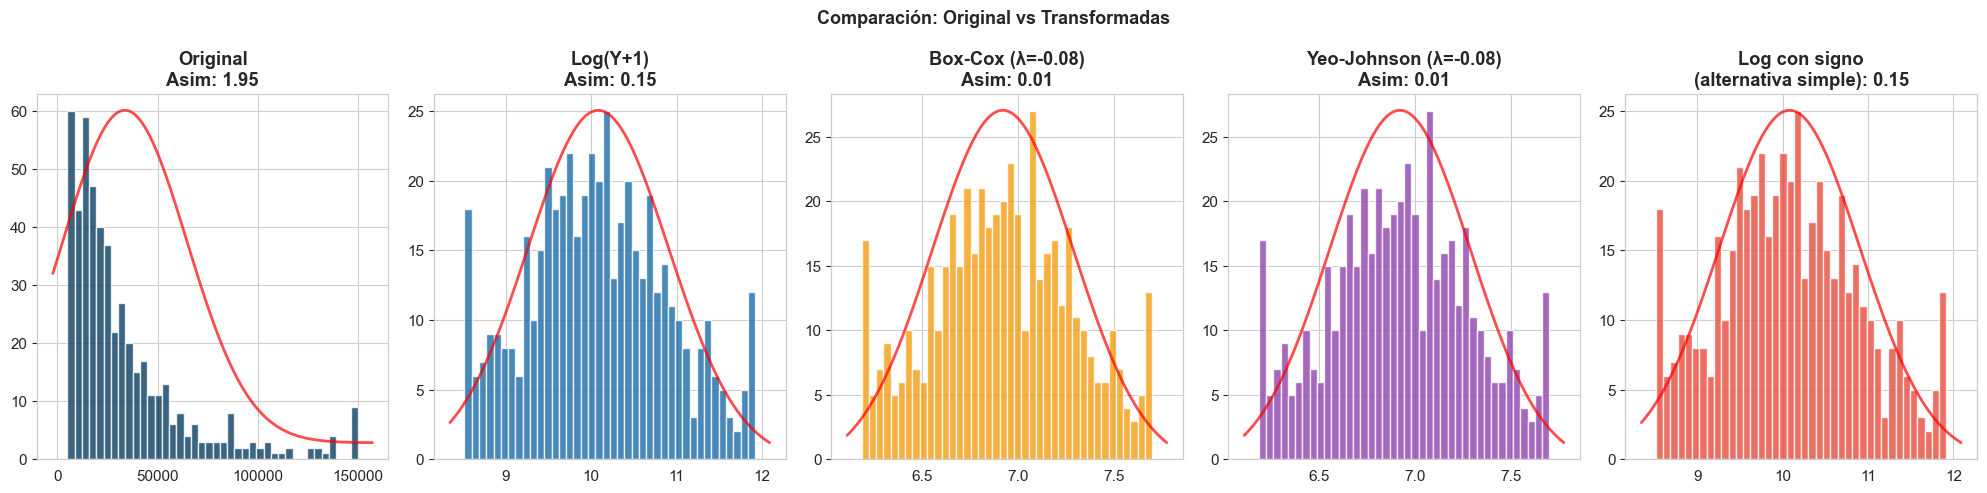

In [13]:
# Tranformacion Log Box- Cox para prima anual.
from scipy.stats import boxcox, yeojohnson
from scipy import stats

y = df['prima_anual'].values
y_boxcox, lambda_optimo = boxcox(df['prima_anual'])
y_yj, lambda_yj = yeojohnson(y)
y_log_abs = np.sign(y) * np.log1p(np.abs(y)) 

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
datos = [y, np.log1p(y), y_boxcox, y_yj, y_log_abs]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y+1)\nAsim: {stats.skew(np.log1p(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo:.2f})\nAsim: {stats.skew(y_boxcox):.2f}',
          f'Yeo-Johnson (λ={lambda_yj:.2f})\nAsim: {stats.skew(y_yj):.2f}',
          f'Log con signo\n(alternativa simple): {stats.skew(y_log_abs):.2f}']
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD', '#E74C3C']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxcox_transform.png', dpi=120, bbox_inches='tight')
plt.show()



In [14]:
from scipy.stats import shapiro

variables_test = {
    'Original': df['prima_anual'].sample(500),
    'Box-Cox': pd.Series(y_boxcox).sample(500),
    'Log(Y+1)': pd.Series(np.log1p(y)).sample(500),
    'Yeo-Johnson': pd.Series(y_yj).sample(500),
    'Alternativa manual': pd.Series(y_log_abs).sample(500),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.7745 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9876 | p-valor: 0.000292 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9862 | p-valor: 0.000115 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.9876 | p-valor: 0.000292 | ❌ No normal
Alternativa manual | Estadístico: 0.9862 | p-valor: 0.000115 | ❌ No normal
